<a href="https://colab.research.google.com/github/keshariujjwal51/Ujjwal/blob/main/AI_Load_Advisory_Chatbot_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 AI Loan Advisory Agent
### Machine Learning + Explainable AI + LLM-Assisted Loan Advisory System

&nbsp;|&nbsp; **Platform:** Google Colab &nbsp;|&nbsp; **Language:** Python 3.11

---


## 1. Introduction

### Problem Statement
Loan approval is a critical, high-stakes decision made by banks and financial institutions every day. Manually evaluating each applicant's profile—including income, credit history, and employment—is slow and prone to human bias. Furthermore, applicants often lack transparency regarding **why** their application was approved or rejected.

### Objective
This notebook builds an **AI Loan Advisory Agent** that:
1. **Predicts** loan approval likelihood using 7 different machine learning models (Logistic Regression, Random Forest, etc.).
2. **Explains** decisions in human-readable English using **SHAP** (Explainable AI).
3. **Advises** applicants with both deterministic rule-based suggestions and LLM-assisted (Gemini/OpenAI) natural language guidance.
4. Exposes the entire system through an interactive **Gradio web app**.

### Dataset Overview
We utilize the official **Loan Prediction Dataset** from Kaggle ([altruistdelhite04/loan-prediction-problem-dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)). This dataset contains 614 historical loan applications.

| Column | Description |
|---|---|
| `Loan_ID` | Unique loan application ID |
| `Gender` | Male / Female |
| `Married` | Applicant married (Y/N) |
| `Dependents` | Number of dependents (0, 1, 2, 3+) |
| `Education` | Graduate / Not Graduate |
| `Self_Employed` | Self employed (Y/N) |
| `ApplicantIncome` | Applicant's monthly income |
| `CoapplicantIncome` | Co-applicant's monthly income |
| `LoanAmount` | Loan amount requested (in thousands) |
| `Loan_Amount_Term` | Term of loan in months |
| `Credit_History` | Meets credit guidelines (1.0 = Yes, 0.0 = No) |
| `Property_Area` | Urban / Semiurban / Rural |
| `Loan_Status` | **Target** — Y = Approved, N = Rejected |

> **Data Source:** This notebook dynamically fetches the dataset using `kagglehub`, ensuring we work with the latest version of the official data.

### Expected Output
For any given applicant profile, the agent produces:
- **Classification:** Approved or Rejected.
- **Probability:** The statistical likelihood of approval (e.g., 79.62%).
- **SHAP Explanation:** Identifying specific drivers (e.g., *"Credit History supports approval"*).
- **Actionable Advice:** Concrete steps to improve approval odds (e.g., *"Consider adding a co-applicant"*).

## 2. Install Dependencies

Run this cell first when using a fresh Google Colab runtime. All packages are pinned loosely to avoid
version conflicts. This is safe to re-run — pip will skip already-satisfied requirements.


In [1]:
# Core data science + ML stack
!pip install -q pandas numpy matplotlib plotly scikit-learn

# Gradient boosting libraries
!pip install -q xgboost lightgbm catboost

# Explainable AI
!pip install -q shap

# Web UI
!pip install -q gradio

# Utilities
!pip install -q joblib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


## 3. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import kagglehub

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Explainability
import shap

# UI
import gradio as gr

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 4. Load Dataset

The dataset is loaded from `loan.csv`, placed alongside this notebook (see folder structure in the README).
If you're running this fresh in Colab and don't have the file yet, the commented cell below will fetch it.


In [3]:
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Path to dataset files: /kaggle/input/loan-prediction-problem-dataset


In [9]:
import os
# List files to find the correct filename
files = os.listdir(path)
print(f"Files in dataset path: {files}")

# The dataset typically contains 'train_u6lujMm.csv' or 'test_Y3wMUE5.csv'
# We will look for the training file (usually the one with 'train' or the larger one)
target_file = [f for f in files if f.startswith('train') and f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, target_file))
df.info()

Files in dataset path: ['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,367,367,LP002989,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,356,2,Male,286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,367,2,Yes,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,357,4,0,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,367,2,Graduate,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,344,2,No,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,367.0,NaN,NaN,NaN,4805.599455,4910.685399,0.0,2864.0,3786.0,5060.0,72529.0
CoapplicantIncome,367.0,NaN,NaN,NaN,1569.577657,2334.232099,0.0,0.0,1025.0,2430.5,24000.0
LoanAmount,362.0,NaN,NaN,NaN,136.132597,61.366652,28.0,100.25,125.0,158.0,550.0
Loan_Amount_Term,361.0,NaN,NaN,NaN,342.537396,65.156643,6.0,360.0,360.0,360.0,480.0


## 5. Exploratory Data Analysis

We explore missing values, distributions, and relationships between key features and the target
variable (`Loan_Status`) to build intuition before modeling.


### 5.1 Missing Values

                  Missing Count  Missing %
Credit_History               29       7.90
Self_Employed                23       6.27
Gender                       11       3.00
Dependents                   10       2.72
Loan_Amount_Term              6       1.63
LoanAmount                    5       1.36


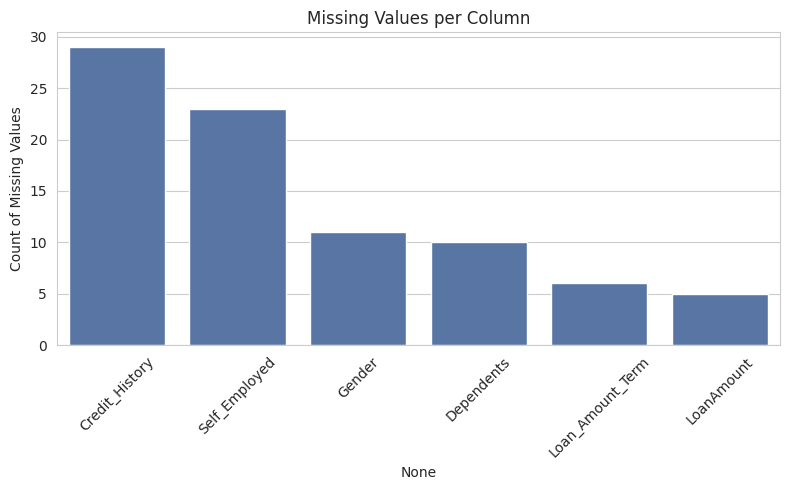

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df)

# Create the images directory if it doesn't exist to prevent FileNotFoundError
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_df.index, y=missing_df["Missing Count"], color="#4C72B0")
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/missing_values.png", dpi=120)
plt.show()

### 5.2 Loan Status Distribution (Target Variable)

In [10]:
fig = px.pie(df, names="Loan_Status", title="Loan Status Distribution",
             color="Loan_Status", color_discrete_map={"Y": "#2ecc71", "N": "#e74c3c"}, hole=0.35)
fig.update_traces(textinfo="percent+label")
fig.write_image("images/loan_status_distribution.png") if False else None
fig.show()

print(df["Loan_Status"].value_counts())
print(df["Loan_Status"].value_counts(normalize=True).round(3) * 100)


Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y    68.7
N    31.3
Name: proportion, dtype: float64


### 5.3 Income Distribution

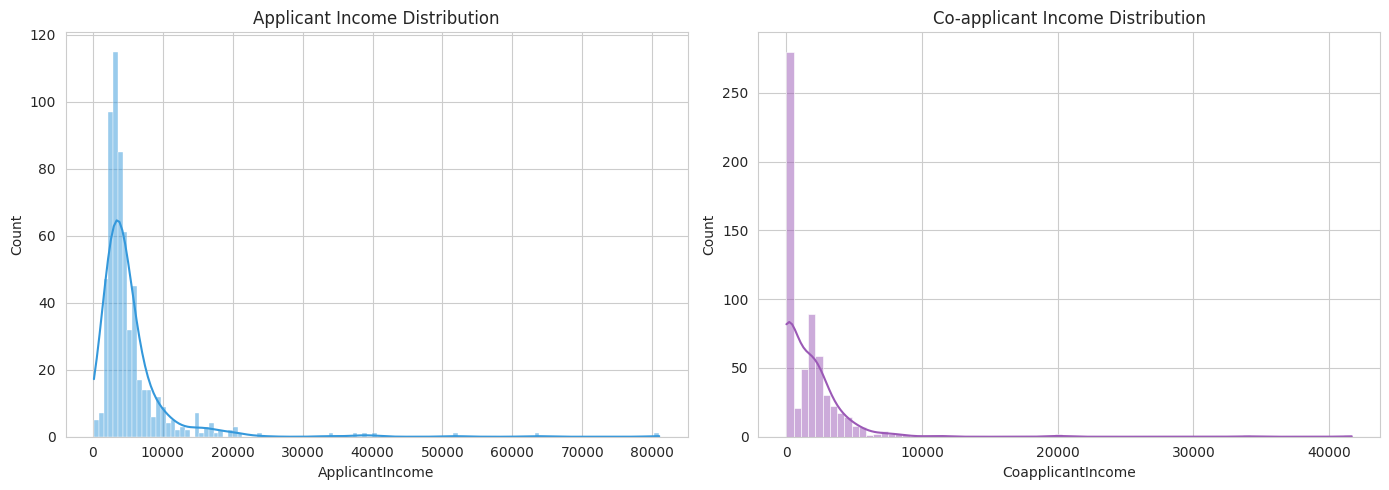

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["ApplicantIncome"], kde=True, ax=axes[0], color="#3498db")
axes[0].set_title("Applicant Income Distribution")
sns.histplot(df["CoapplicantIncome"], kde=True, ax=axes[1], color="#9b59b6")
axes[1].set_title("Co-applicant Income Distribution")
plt.tight_layout()
plt.savefig("images/income_distribution.png", dpi=120)
plt.show()


### 5.4 Loan Amount Distribution

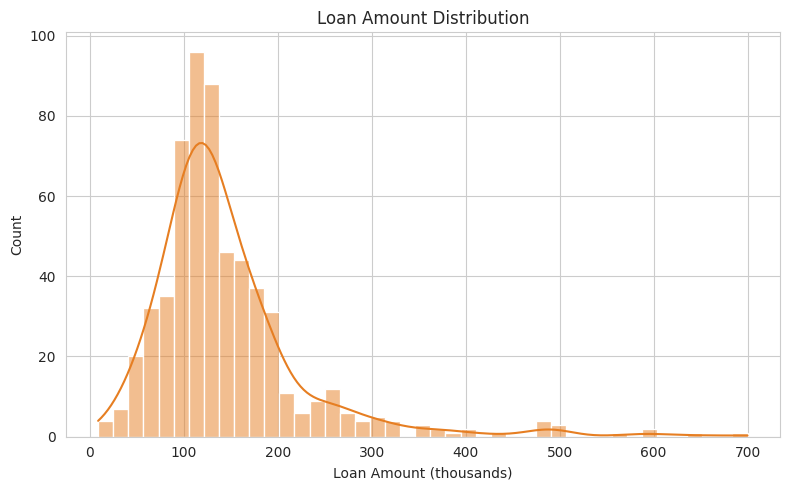

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["LoanAmount"].dropna(), kde=True, color="#e67e22")
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount (thousands)")
plt.tight_layout()
plt.savefig("images/loan_amount_distribution.png", dpi=120)
plt.show()


### 5.5 Correlation Matrix

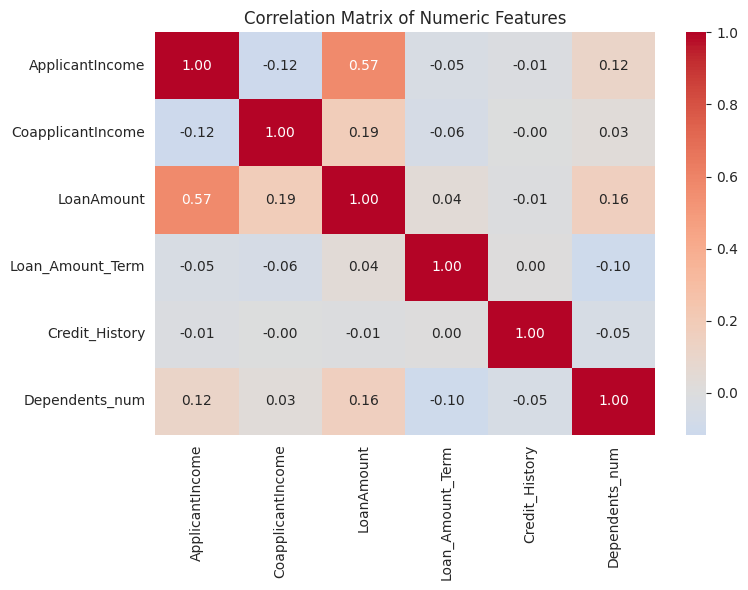

In [13]:
numeric_df = df.copy()
numeric_df["Dependents_num"] = numeric_df["Dependents"].replace("3+", 3).astype(float)
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
                "Loan_Amount_Term", "Credit_History", "Dependents_num"]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig("images/correlation_matrix.png", dpi=120)
plt.show()


### 5.6 Applicant Income vs Loan Status

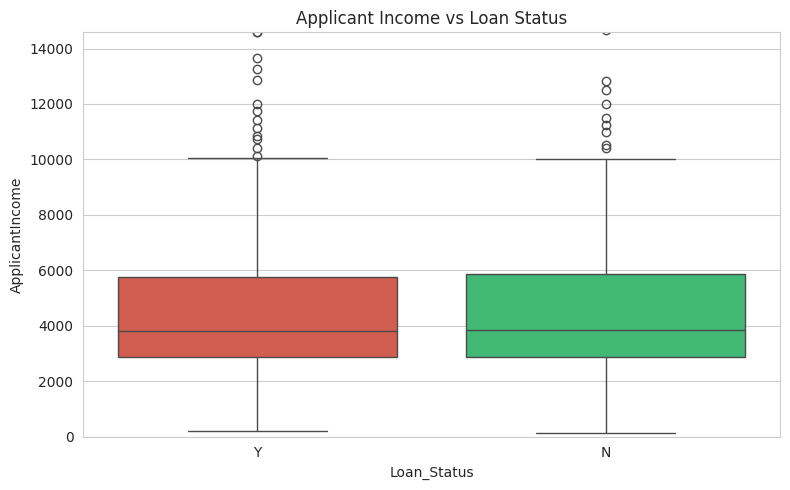

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Loan_Status", y="ApplicantIncome", palette=["#e74c3c", "#2ecc71"])
plt.title("Applicant Income vs Loan Status")
plt.ylim(0, df["ApplicantIncome"].quantile(0.95))
plt.tight_layout()
plt.savefig("images/income_vs_status.png", dpi=120)
plt.show()


### 5.7 Education vs Loan Status

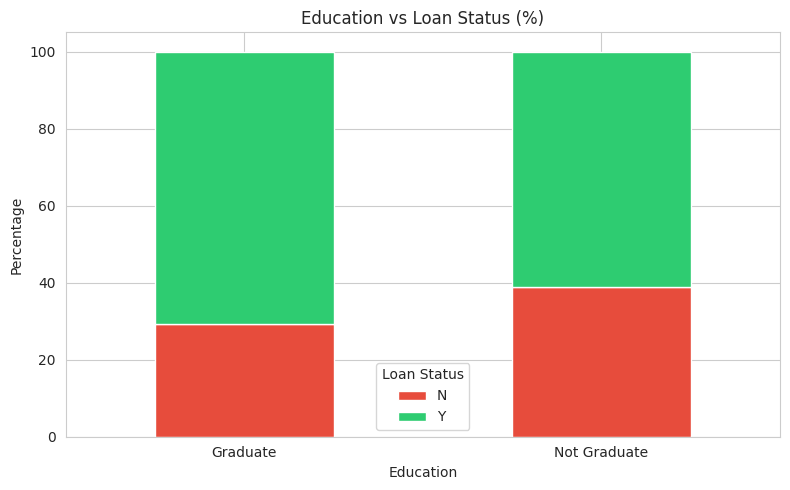

In [15]:
ct = pd.crosstab(df["Education"], df["Loan_Status"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], figsize=(8, 5))
plt.title("Education vs Loan Status (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.tight_layout()
plt.savefig("images/education_vs_status.png", dpi=120)
plt.show()


### 5.8 Credit History vs Loan Status

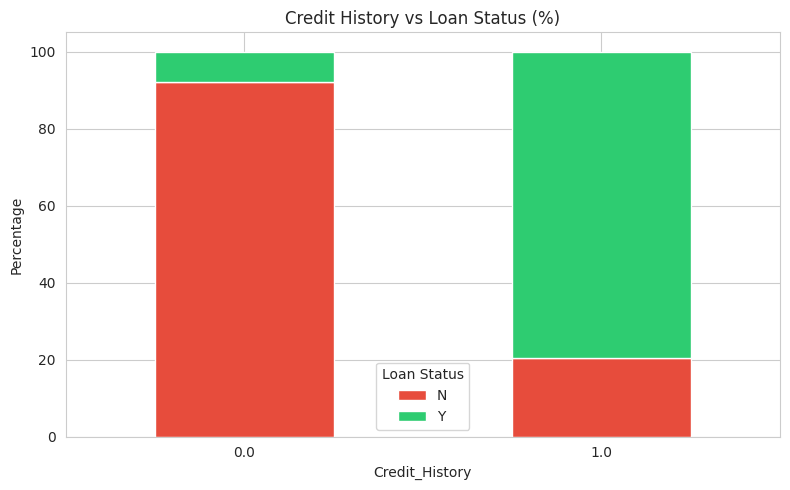

Approval rate with Credit_History = 1: 79.6%
Approval rate with Credit_History = 0: 7.9%


In [16]:
ct = pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], figsize=(8, 5))
plt.title("Credit History vs Loan Status (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.tight_layout()
plt.savefig("images/credit_history_vs_status.png", dpi=120)
plt.show()

print("Approval rate with Credit_History = 1:",
      f'{(df[df.Credit_History==1]["Loan_Status"]=="Y").mean():.1%}')
print("Approval rate with Credit_History = 0:",
      f'{(df[df.Credit_History==0]["Loan_Status"]=="Y").mean():.1%}')


### 5.9 Property Area Distribution

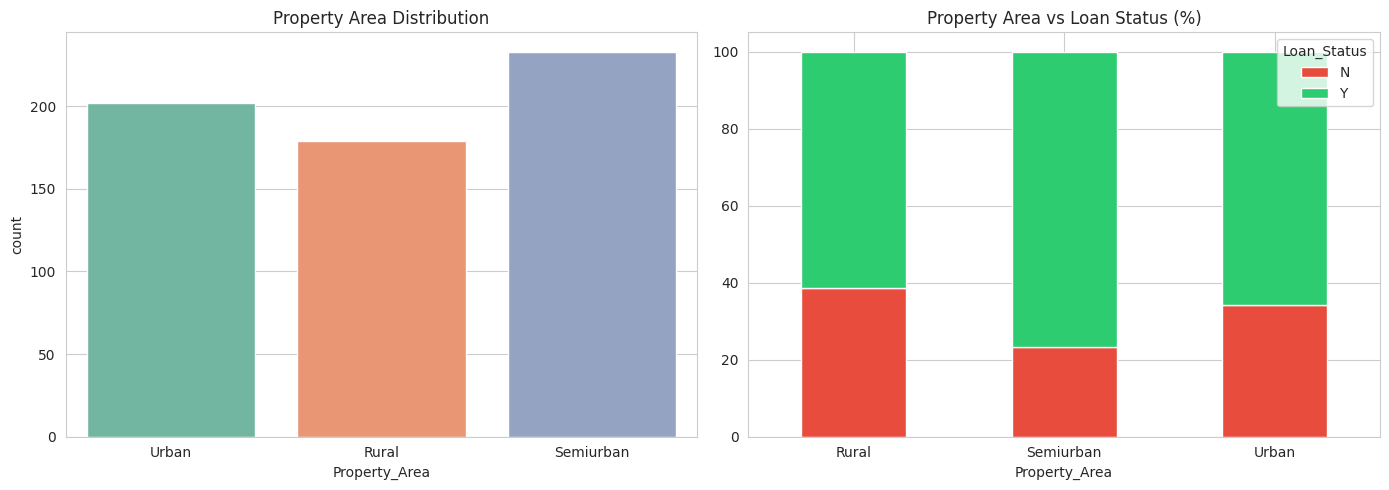

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="Property_Area", ax=axes[0], palette="Set2")
axes[0].set_title("Property Area Distribution")

ct = pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], ax=axes[1])
axes[1].set_title("Property Area vs Loan Status (%)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("images/property_area.png", dpi=120)
plt.show()


## 6. Data Cleaning

We build a reusable **`LoanDataPreprocessor`** class that performs missing-value imputation, label encoding,
one-hot encoding, and feature scaling. Wrapping this in a class (rather than one-off script steps) means the
*exact same* transformation logic can be reused later for single-applicant predictions in `predict_loan()` and
the Gradio app — avoiding duplicate code and guaranteeing train/inference consistency.


In [18]:
class LoanDataPreprocessor:
    """
    Handles missing value imputation, encoding, and scaling for the Loan Prediction dataset.
    Fit once on training data, then reuse `transform()` for any new applicant data.
    """

    NUMERIC_COLS = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Dependents"]
    BINARY_CAT_COLS = ["Gender", "Married", "Education", "Self_Employed"]
    ONEHOT_COL = "Property_Area"

    def __init__(self):
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.feature_columns = None
        self.impute_values = {}

    def _basic_clean(self, df):
        df = df.copy()
        df["Dependents"] = df["Dependents"].astype(str).replace("3+", "3")
        df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")
        return df

    def fit_transform(self, df):
        df = self._basic_clean(df)

        # --- Missing value imputation (mode for categorical, median for numeric) ---
        for col in ["Gender", "Married", "Self_Employed"]:
            self.impute_values[col] = df[col].mode()[0]
            df[col] = df[col].fillna(self.impute_values[col])

        for col in ["Dependents", "LoanAmount", "Loan_Amount_Term", "Credit_History"]:
            self.impute_values[col] = df[col].median()
            df[col] = df[col].fillna(self.impute_values[col])

        # --- Label Encoding for binary categorical columns ---
        for col in self.BINARY_CAT_COLS:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self.label_encoders[col] = le

        # --- One-Hot Encoding for Property_Area ---
        df = pd.get_dummies(df, columns=[self.ONEHOT_COL], prefix="Area")
        bool_cols = df.select_dtypes(include="bool").columns
        df[bool_cols] = df[bool_cols].astype(int)

        # --- Feature Scaling ---
        df[self.NUMERIC_COLS] = self.scaler.fit_transform(df[self.NUMERIC_COLS])

        drop_cols = [c for c in ["Loan_ID", "Loan_Status"] if c in df.columns]
        X = df.drop(columns=drop_cols)
        self.feature_columns = X.columns.tolist()
        return X

    def transform(self, df):
        df = self._basic_clean(df)

        for col in ["Gender", "Married", "Self_Employed"]:
            df[col] = df[col].fillna(self.impute_values.get(col))
        for col in ["Dependents", "LoanAmount", "Loan_Amount_Term", "Credit_History"]:
            df[col] = df[col].fillna(self.impute_values.get(col))

        for col in self.BINARY_CAT_COLS:
            le = self.label_encoders[col]
            df[col] = df[col].astype(str).apply(lambda v: v if v in le.classes_ else le.classes_[0])
            df[col] = le.transform(df[col])

        df = pd.get_dummies(df, columns=[self.ONEHOT_COL], prefix="Area")
        bool_cols = df.select_dtypes(include="bool").columns
        df[bool_cols] = df[bool_cols].astype(int)

        df[self.NUMERIC_COLS] = self.scaler.transform(df[self.NUMERIC_COLS])

        drop_cols = [c for c in ["Loan_ID", "Loan_Status"] if c in df.columns]
        X = df.drop(columns=drop_cols, errors="ignore")

        # Align columns with training-time feature set
        for c in self.feature_columns:
            if c not in X.columns:
                X[c] = 0
        X = X[self.feature_columns]
        return X


preprocessor = LoanDataPreprocessor()
X = preprocessor.fit_transform(df)
y = df["Loan_Status"].map({"Y": 1, "N": 0})

print("Feature matrix shape:", X.shape)
print("Features:", preprocessor.feature_columns)
X.head()


Feature matrix shape: (614, 13)
Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Area_Rural', 'Area_Semiurban', 'Area_Urban']


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Area_Rural,Area_Semiurban,Area_Urban
0,1,0,-0.737806,0,0,0.072991,-0.554487,-0.211241,0.273231,1.0,0,0,1
1,1,1,0.253470,0,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,1,0,0
2,1,1,-0.737806,0,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,0,0,1
3,1,1,-0.737806,1,0,-0.462062,0.251980,-0.306435,0.273231,1.0,0,0,1
4,1,0,-0.737806,0,0,0.097728,-0.554487,-0.056551,0.273231,1.0,0,0,1


### Train-Test Split (80% / 20%)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Train approval rate: {y_train.mean():.1%}  |  Test approval rate: {y_test.mean():.1%}")


Training set: 491 rows
Test set:     123 rows
Train approval rate: 68.6%  |  Test approval rate: 69.1%


## 7. Model Building

We train seven classification models spanning linear, tree-based, and gradient-boosted approaches, so we
can compare and pick the best performer objectively in Section 9.


In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ Trained: {name}")


✅ Trained: Logistic Regression
✅ Trained: Decision Tree
✅ Trained: Random Forest
✅ Trained: Gradient Boosting
✅ Trained: XGBoost
✅ Trained: LightGBM
✅ Trained: CatBoost


## 8. Model Evaluation

For each trained model we compute Accuracy, Precision, Recall, F1 Score, and ROC AUC, plus confusion
matrices and full classification reports.


In [21]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba


evaluation_results = []
predictions_store = {}

for name, model in trained_models.items():
    metrics, y_pred, y_proba = evaluate_model(name, model, X_test, y_test)
    evaluation_results.append(metrics)
    predictions_store[name] = (y_pred, y_proba)

results_df = pd.DataFrame(evaluation_results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8486
1,Random Forest,0.8537,0.8317,0.9882,0.9032,0.8186
2,Decision Tree,0.8211,0.8247,0.9412,0.8791,0.7259
3,CatBoost,0.8211,0.8387,0.9176,0.8764,0.7861
4,Gradient Boosting,0.8130,0.8229,0.9294,0.8729,0.7659
5,LightGBM,0.8049,0.8588,0.8588,0.8588,0.7889
6,XGBoost,0.7886,0.8315,0.8706,0.8506,0.7765


### Confusion Matrices

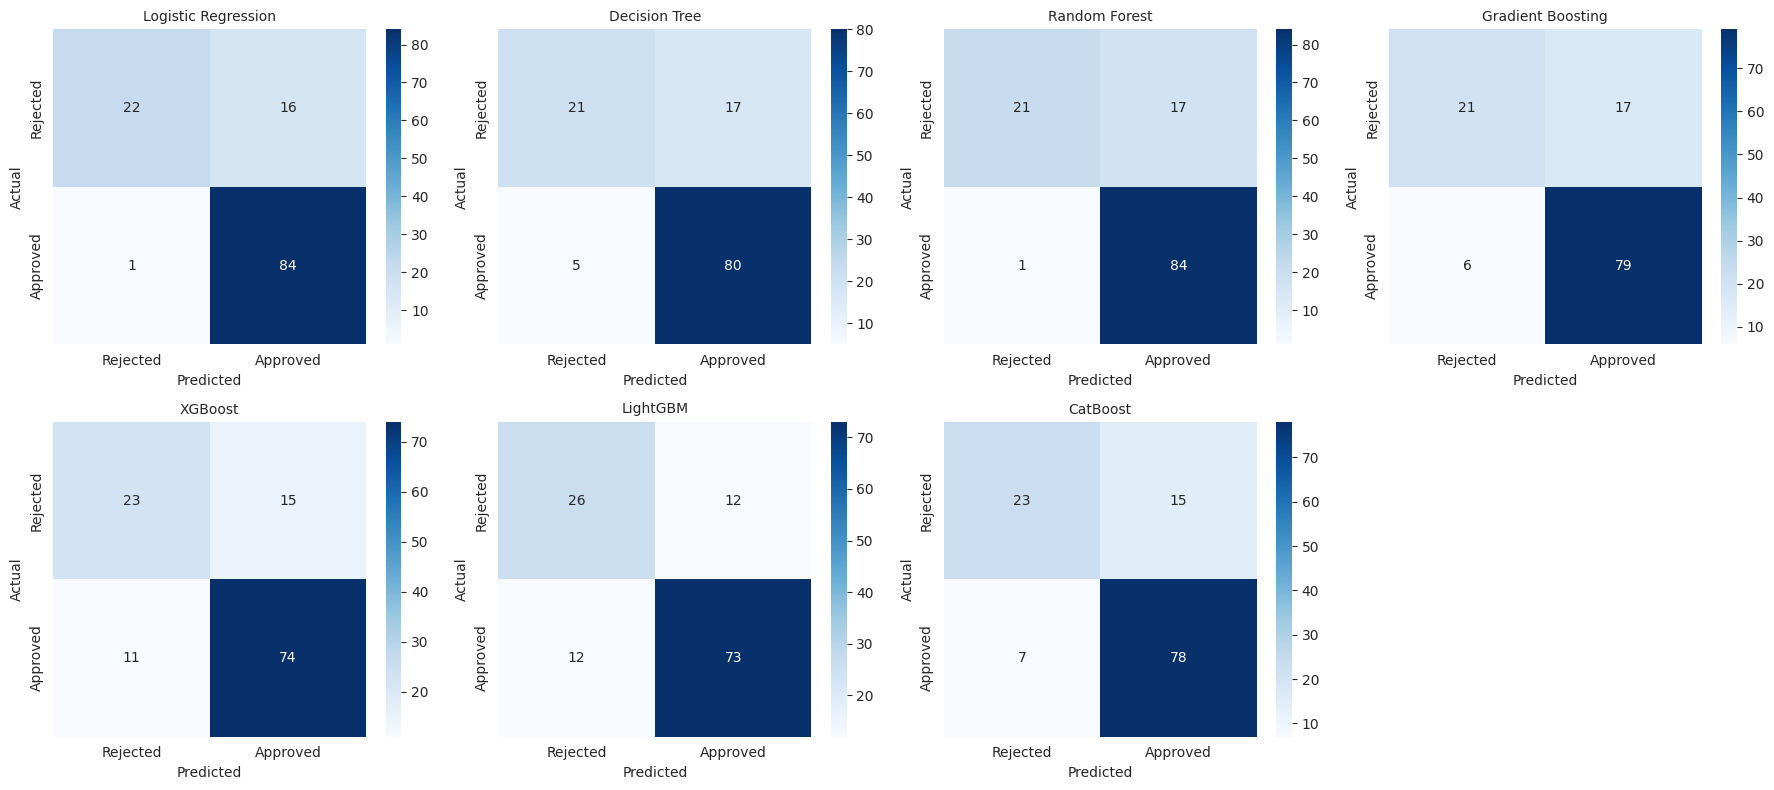

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred, _ = predictions_store[name]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(len(trained_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("images/confusion_matrices.png", dpi=120)
plt.show()


### Classification Reports

In [23]:
for name, model in trained_models.items():
    y_pred, _ = predictions_store[name]
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))



Logistic Regression
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Decision Tree
              precision    recall  f1-score   support

    Rejected       0.81      0.55      0.66        38
    Approved       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123


Random Forest
              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87

### ROC Curves

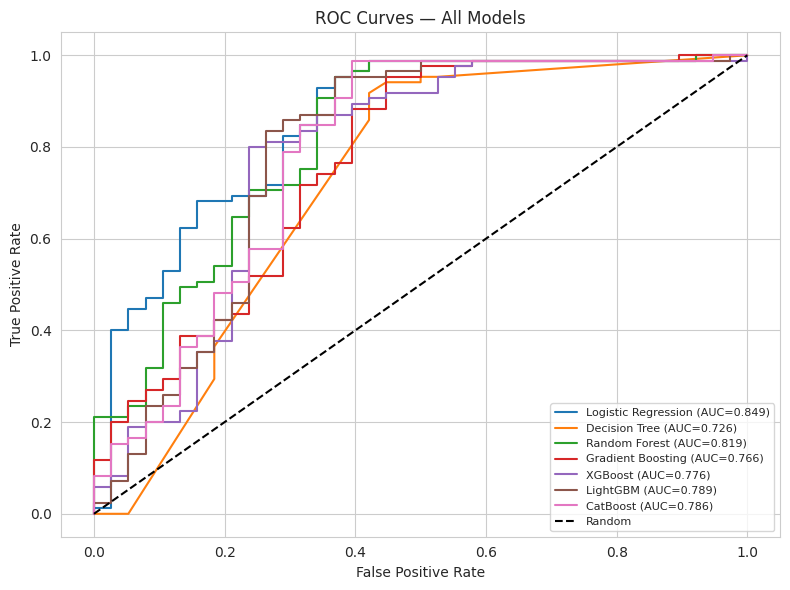

In [24]:
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    _, y_proba = predictions_store[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("images/roc_curves.png", dpi=120)
plt.show()


## 9. Model Comparison & Best Model Selection

We rank all models by F1 Score (a balanced measure given the moderate class imbalance in `Loan_Status`),
select the top performer, and persist it with `joblib` for reuse in the advisory agent and Gradio app.


In [25]:
import os
# Create the outputs directory if it doesn't exist
os.makedirs("outputs", exist_ok=True)

comparison_table = results_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].copy()
comparison_table.to_csv("outputs/model_comparison.csv", index=False)
comparison_table.style.background_gradient(cmap="Greens", subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108,0.848607
1,Random Forest,0.853659,0.831683,0.988235,0.903226,0.818576
2,Decision Tree,0.821138,0.824742,0.941176,0.879121,0.725851
3,CatBoost,0.821138,0.838710,0.917647,0.876404,0.786068
4,Gradient Boosting,0.813008,0.822917,0.929412,0.872928,0.765944
5,LightGBM,0.804878,0.858824,0.858824,0.858824,0.788854
6,XGBoost,0.788618,0.831461,0.870588,0.850575,0.776471


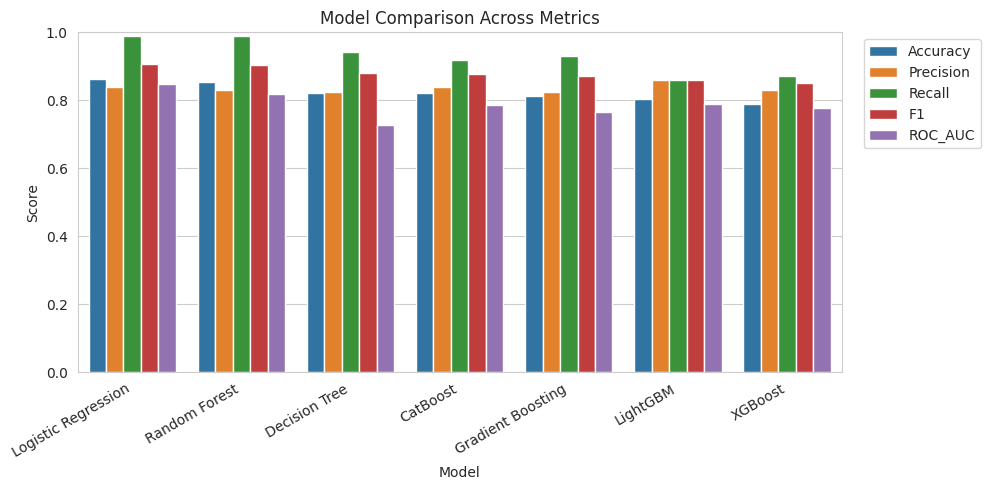

In [26]:
plt.figure(figsize=(10, 5))
plot_df = comparison_table.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison Across Metrics")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("images/model_comparison.png", dpi=120)
plt.show()


In [27]:
best_model_name = comparison_table.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(comparison_table.iloc[0])

joblib.dump(best_model, "loan_model.pkl")
joblib.dump(preprocessor, "loan_preprocessor.pkl")
print("\n✅ Saved best_model -> loan_model.pkl")
print("✅ Saved preprocessor -> loan_preprocessor.pkl")


🏆 Best Model: Logistic Regression
Model        Logistic Regression
Accuracy                0.861789
Precision                   0.84
Recall                  0.988235
F1                      0.908108
ROC_AUC                 0.848607
Name: 0, dtype: object

✅ Saved best_model -> loan_model.pkl
✅ Saved preprocessor -> loan_preprocessor.pkl


## 10. Explainable AI (SHAP)

A prediction is only useful if we can explain *why* it was made. We use **SHAP (SHapley Additive exPlanations)**
on the best model to compute global feature importance and per-applicant explanations.


In [28]:
# shap.Explainer auto-selects the right algorithm (Tree, Linear, etc.) for the given model type
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# For binary classifiers some SHAP explainers return a 3D array (samples, features, classes) — normalize to 2D
if len(shap_values.shape) == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print("SHAP values computed for", shap_values_pos.shape[0], "test applicants.")


SHAP values computed for 123 test applicants.


### 10.1 Global Feature Importance

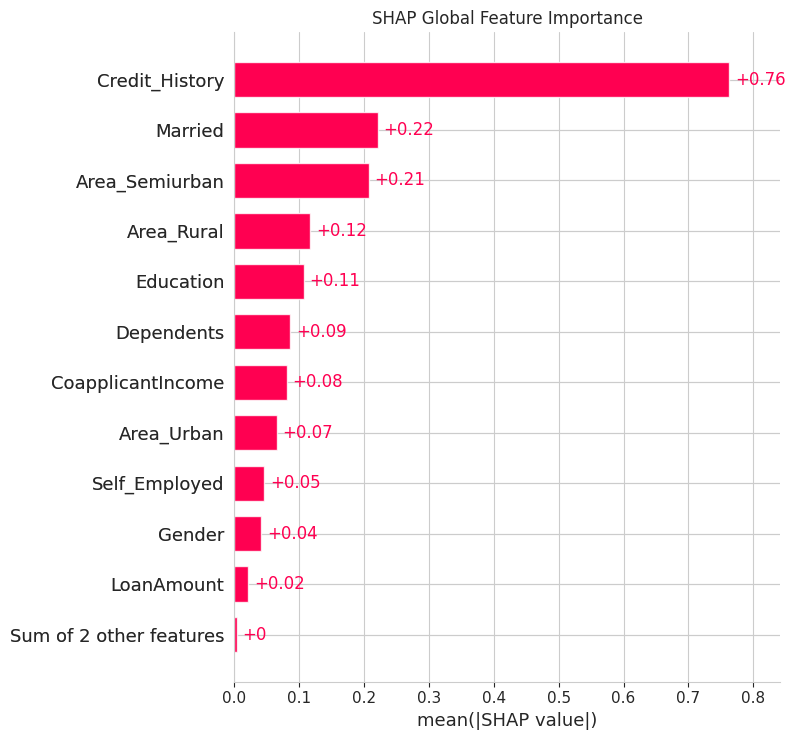

In [29]:
plt.figure()
shap.plots.bar(shap_values_pos, show=False, max_display=12)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig("images/shap_feature_importance.png", dpi=120)
plt.show()


### 10.2 SHAP Summary Plot

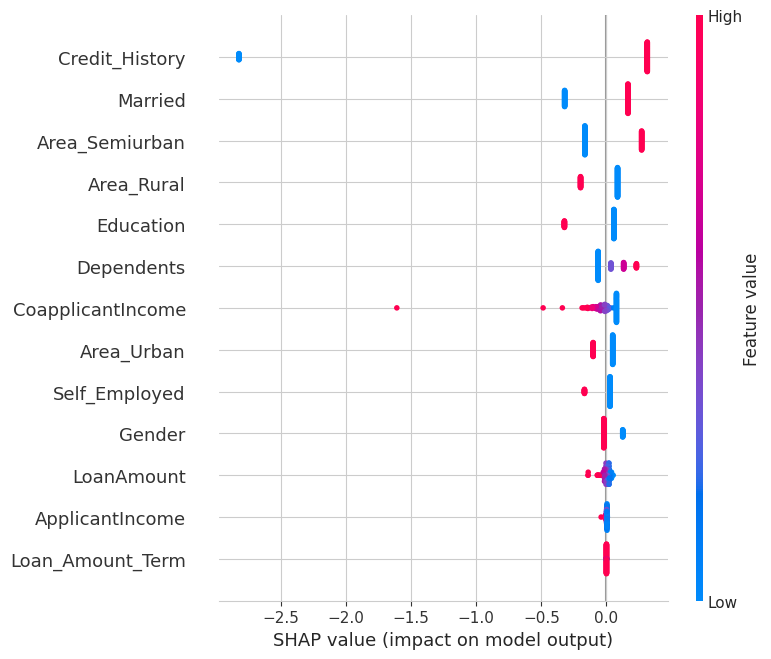

In [30]:
plt.figure()
shap.summary_plot(shap_values_pos, X_test, show=False)
plt.tight_layout()
plt.savefig("images/shap_summary.png", dpi=120)
plt.show()


### 10.3 SHAP Waterfall / Force Plot for a Single Applicant

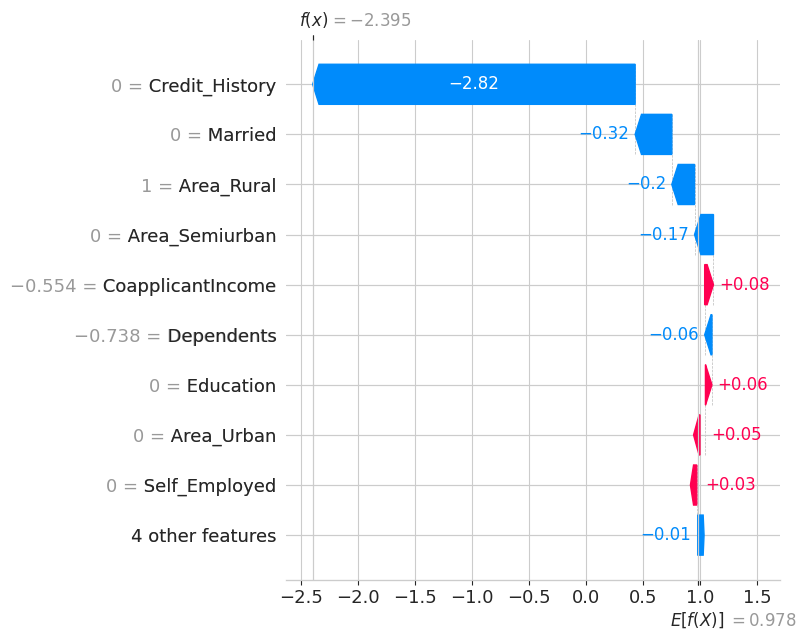

Applicant (test set) row used above:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Area_Rural,Area_Semiurban,Area_Urban
150,1,0,-0.737806,0,0,0.143108,-0.554487,-0.330234,0.273231,0.0,1,0,0


In [31]:
sample_idx = 0
plt.figure()
shap.plots.waterfall(shap_values_pos[sample_idx], show=False, max_display=10)
plt.tight_layout()
plt.savefig("images/shap_waterfall_sample.png", dpi=120)
plt.show()

print("Applicant (test set) row used above:")
X_test.iloc[[sample_idx]]


### 10.4 Turning SHAP Values into a Plain-English Explanation

The function below converts raw SHAP contributions into human-readable reasons, e.g.:

> Loan Approved because: High Credit History · Stable Income · Graduate · Low Loan Amount


In [32]:
FEATURE_LABELS = {
    "Credit_History": "Credit History",
    "ApplicantIncome": "Applicant Income",
    "CoapplicantIncome": "Co-applicant Income",
    "LoanAmount": "Loan Amount",
    "Loan_Amount_Term": "Loan Term",
    "Education": "Education Level",
    "Married": "Marital Status",
    "Gender": "Gender",
    "Self_Employed": "Employment Type",
    "Dependents": "Number of Dependents",
    "Area_Urban": "Urban Property Area",
    "Area_Semiurban": "Semiurban Property Area",
    "Area_Rural": "Rural Property Area",
}


def explain_with_shap(explainer, X_row, top_n=4):
    """
    Returns a list of plain-English reasons for a single-row DataFrame `X_row`,
    ranked by absolute SHAP contribution towards the predicted class.
    """
    sv = explainer(X_row)
    if len(sv.shape) == 3:
        sv = sv[:, :, 1]

    contributions = pd.Series(sv.values[0], index=X_row.columns)
    row_values = X_row.iloc[0]

    # One-hot "Area_*" columns that are 0 (i.e. not the applicant's actual property area)
    # are excluded from ranking — an unselected category shouldn't be reported as an
    # active driver of the decision, even though it may carry a nonzero SHAP value.
    inactive_onehot = [c for c in X_row.columns if c.startswith("Area_") and row_values[c] == 0]
    eligible_contributions = contributions.drop(index=inactive_onehot)

    top_features = eligible_contributions.abs().sort_values(ascending=False).head(top_n).index

    reasons = []
    for feat in top_features:
        label = FEATURE_LABELS.get(feat, feat)
        direction = "supports approval" if contributions[feat] > 0 else "works against approval"
        reasons.append(f"{label} {direction}")
    return reasons


sample_reasons = explain_with_shap(explainer, X_test.iloc[[0]])
print("Example explanation:")
for r in sample_reasons:
    print(" -", r)


Example explanation:
 - Credit History works against approval
 - Marital Status works against approval
 - Rural Property Area works against approval
 - Co-applicant Income supports approval


## 11. Loan Prediction Function

`predict_loan()` is the core reusable function of this agent: given raw applicant details, it runs them through
the **same preprocessing pipeline** used in training, predicts with the **best model**, and generates a
plain-English explanation via SHAP.


In [33]:
def predict_loan(Gender="Male", Married="Yes", Dependents="0", Education="Graduate",
                  Self_Employed="No", ApplicantIncome=5000, CoapplicantIncome=0,
                  LoanAmount=150, Loan_Amount_Term=360, Credit_History=1,
                  Property_Area="Urban"):
    """
    Predict loan approval for a single applicant.

    Returns a dict with: prediction, probability, confidence, and reasons (list of strings).
    """
    applicant = pd.DataFrame([{
        "Gender": Gender, "Married": Married, "Dependents": Dependents,
        "Education": Education, "Self_Employed": Self_Employed,
        "ApplicantIncome": ApplicantIncome, "CoapplicantIncome": CoapplicantIncome,
        "LoanAmount": LoanAmount, "Loan_Amount_Term": Loan_Amount_Term,
        "Credit_History": Credit_History, "Property_Area": Property_Area,
    }])

    X_applicant = preprocessor.transform(applicant)

    proba = best_model.predict_proba(X_applicant)[0]
    pred_class = int(np.argmax(proba))
    probability_approved = float(proba[1])
    confidence = float(proba[pred_class])

    reasons = explain_with_shap(explainer, X_applicant)

    return {
        "prediction": "Approved" if pred_class == 1 else "Rejected",
        "probability_approved": round(probability_approved * 100, 2),
        "confidence": round(confidence * 100, 2),
        "reasons": reasons,
        "applicant": applicant.iloc[0].to_dict(),
    }


# --- Example matching the notebook's target scenario ---
result = predict_loan(
    Gender="Male", Married="Yes", Dependents="0", Education="Graduate",
    Self_Employed="No", ApplicantIncome=6500, CoapplicantIncome=0,
    LoanAmount=120, Loan_Amount_Term=360, Credit_History=1, Property_Area="Urban",
)

print(f"Loan {result['prediction']}")
print(f"Probability: {result['probability_approved']}%")
print(f"Confidence: {result['confidence']}%")
print("Reason:")
for r in result["reasons"]:
    print(" -", r)


Loan Approved
Probability: 79.62%
Confidence: 79.62%
Reason:
 - Credit History supports approval
 - Marital Status supports approval
 - Urban Property Area works against approval
 - Co-applicant Income supports approval


## 12. AI Loan Advisor

The `ai_loan_advisor()` function wraps `predict_loan()` into a friendly, formatted advisory response —
the kind of answer a human loan officer might give when asked *"Can I get a loan?"*.


In [34]:
def ai_loan_advisor(**applicant_kwargs):
    result = predict_loan(**applicant_kwargs)
    a = result["applicant"]

    lines = []
    lines.append("Based on your profile:\n")
    lines.append(f"  Income               : ₹{a['ApplicantIncome']:,}")
    lines.append(f"  Co-applicant Income  : ₹{a['CoapplicantIncome']:,}")
    lines.append(f"  Loan Amount Requested: ₹{a['LoanAmount']:,} (thousands)")
    lines.append(f"  Credit History       : {a['Credit_History']}")
    lines.append(f"  Property Area        : {a['Property_Area']}")
    lines.append(f"\n  Approval Probability : {result['probability_approved']}%")

    if result["probability_approved"] >= 70:
        recommendation = "High chance of approval."
    elif result["probability_approved"] >= 40:
        recommendation = "Moderate chance of approval — consider the suggestions below."
    else:
        recommendation = "Low chance of approval — see recommendations below to improve your profile."

    lines.append(f"\n  Recommendation       : {recommendation}")
    lines.append("\n  Why:")
    for r in result["reasons"]:
        lines.append(f"    • {r}")

    advisory_text = "\n".join(lines)
    print(advisory_text)
    return {**result, "advisory_text": advisory_text, "recommendation": recommendation}


_ = ai_loan_advisor(
    Gender="Female", Married="No", Dependents="0", Education="Graduate",
    Self_Employed="No", ApplicantIncome=2500, CoapplicantIncome=0,
    LoanAmount=180, Loan_Amount_Term=360, Credit_History=0, Property_Area="Rural",
)


Based on your profile:

  Income               : ₹2,500
  Co-applicant Income  : ₹0
  Loan Amount Requested: ₹180 (thousands)
  Credit History       : 0
  Property Area        : Rural

  Approval Probability : 9.37%

  Recommendation       : Low chance of approval — see recommendations below to improve your profile.

  Why:
    • Credit History works against approval
    • Marital Status works against approval
    • Rural Property Area works against approval
    • Gender supports approval


## 13. Rule-Based Advisor

On top of the ML explanation, a lightweight rule-based layer gives concrete, actionable advice —
useful both as a safety net when the model is uncertain, and as clear guidance an applicant can act on.


In [35]:
def rule_based_advice(Gender="Male", Married="Yes", Dependents="0", Education="Graduate",
                       Self_Employed="No", ApplicantIncome=5000, CoapplicantIncome=0,
                       LoanAmount=150, Loan_Amount_Term=360, Credit_History=1,
                       Property_Area="Urban"):
    """Generate actionable suggestions based on simple domain rules."""
    suggestions = []

    if Credit_History == 0:
        suggestions.append("Your credit history does not meet guidelines — work on improving your credit "
                            "score (clear outstanding dues, pay EMIs/credit cards on time) before reapplying.")

    total_income = ApplicantIncome + CoapplicantIncome
    if LoanAmount > 0 and total_income > 0:
        loan_to_income = (LoanAmount * 1000) / total_income
        if loan_to_income > 20:
            suggestions.append("The requested loan amount is high relative to your income — consider "
                                "reducing the requested amount or increasing the loan term to lower EMI burden.")

    if ApplicantIncome < 3000 and CoapplicantIncome == 0:
        suggestions.append("Your individual income is on the lower side — adding a co-applicant "
                            "(e.g. spouse) with steady income can significantly improve approval chances.")

    if Self_Employed == "Yes":
        suggestions.append("Self-employed applicants face extra scrutiny — having consistent ITR filings "
                            "and business financials for the last 2-3 years strengthens your application.")

    if Education == "Not Graduate":
        suggestions.append("While education alone rarely blocks a loan, pairing your application with "
                            "strong income/credit documentation helps offset this factor.")

    if not suggestions:
        suggestions.append("Your profile looks strong across the key factors banks evaluate — no major "
                            "red flags detected.")

    return suggestions


advice = rule_based_advice(
    Married="No", Education="Not Graduate", Self_Employed="Yes",
    ApplicantIncome=2200, CoapplicantIncome=0, LoanAmount=200, Credit_History=0,
)
print("Suggestions:")
for s in advice:
    print(" -", s)


Suggestions:
 - Your credit history does not meet guidelines — work on improving your credit score (clear outstanding dues, pay EMIs/credit cards on time) before reapplying.
 - The requested loan amount is high relative to your income — consider reducing the requested amount or increasing the loan term to lower EMI burden.
 - Your individual income is on the lower side — adding a co-applicant (e.g. spouse) with steady income can significantly improve approval chances.
 - Self-employed applicants face extra scrutiny — having consistent ITR filings and business financials for the last 2-3 years strengthens your application.
 - While education alone rarely blocks a loan, pairing your application with strong income/credit documentation helps offset this factor.


## 14. LLM Integration (Optional)

If a Gemini or OpenAI API key is available as an environment variable (`GOOGLE_API_KEY` / `OPENAI_API_KEY`),
the agent uses it to turn the structured prediction + SHAP reasons into a natural-language explanation.
**If no key is available, it automatically falls back to the rule-based/template explanation** — the
notebook runs end-to-end either way.

> Set your key in Colab with: `import os; os.environ["GOOGLE_API_KEY"] = "your-key-here"` before running this cell.


In [36]:
LLM_SYSTEM_PROMPT = (
    "You are an AI Loan Advisor. Explain the loan prediction in simple English. "
    "Never hallucinate numbers or facts beyond what is given. Keep answers under 150 words."
)

def llm_explain(result: dict, advisor_suggestions: list) -> str:
    """
    Generate a natural-language explanation using an LLM if a key is configured,
    otherwise fall back to a clean template built from the SHAP reasons + rule-based advice.
    """
    context = (
        f"Prediction: {result['prediction']}\n"
        f"Approval probability: {result['probability_approved']}%\n"
        f"Key factors: {'; '.join(result['reasons'])}\n"
        f"Suggestions: {'; '.join(advisor_suggestions)}"
    )

    # --- Try Gemini ---
    # Check for the actual environment variable name
    gemini_key = os.environ.get("GOOGLE_API_KEY")
    if gemini_key:
        try:
            import google.generativeai as genai
            genai.configure(api_key=" ")
            #Enter your API Key
            model = genai.GenerativeModel("gemini-1.5-flash", system_instruction=LLM_SYSTEM_PROMPT)
            response = model.generate_content(context)
            return response.text.strip()
        except ImportError:
            print("google-generativeai not installed — run `!pip install google-generativeai`. Falling back.")
        except Exception as e:
            print(f"Gemini call failed ({e}); falling back to template explanation.")

    # --- Try OpenAI ---
    openai_key = os.environ.get("OPENAI_API_KEY")
    if openai_key:
        try:
            from openai import OpenAI
            client = OpenAI(api_key=" ")
            #Enter your API Key
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": LLM_SYSTEM_PROMPT},
                    {"role": "user", "content": context},
                ],
                max_tokens=200,
            )
            return response.choices[0].message.content.strip()
        except ImportError:
            print("openai package not installed — run `!pip install openai`. Falling back.")
        except Exception as e:
            print(f"OpenAI call failed ({e}); falling back to template explanation.")

    # --- Fallback: local template ---
    fallback = (
        f"Your loan is likely to be **{result['prediction']}** with an estimated "
        f"{result['probability_approved']}% probability of approval. "
        f"This is mainly because: {', '.join(result['reasons']).lower()}. "
    )
    if advisor_suggestions and "no major red flags" not in advisor_suggestions[0]:
        fallback += "To improve your chances: " + " ".join(advisor_suggestions)
    return fallback

# Demo
demo_result = predict_loan(ApplicantIncome=6500, LoanAmount=120, Credit_History=1,
                            Education="Graduate", Married="Yes", Property_Area="Urban")
demo_advice = rule_based_advice(ApplicantIncome=6500, LoanAmount=120, Credit_History=1,
                                 Education="Graduate", Married="Yes", Property_Area="Urban")

explanation = llm_explain(demo_result, demo_advice)
print(explanation)

Your loan is likely to be **Approved** with an estimated 79.62% probability of approval. This is mainly because: credit history supports approval, marital status supports approval, urban property area works against approval, co-applicant income supports approval. 


## 15. Gradio Interface

A simple web UI lets anyone enter applicant details and instantly get a prediction, confidence score,
plain-English explanation, and recommendations — no code required.


In [37]:
def gradio_predict(gender, married, dependents, education, self_employed,
                    applicant_income, coapplicant_income, loan_amount,
                    loan_term, credit_history, property_area):

    credit_history_val = 1 if credit_history == "Yes" else 0

    result = predict_loan(
        Gender=gender, Married=married, Dependents=dependents, Education=education,
        Self_Employed=self_employed, ApplicantIncome=applicant_income,
        CoapplicantIncome=coapplicant_income, LoanAmount=loan_amount,
        Loan_Amount_Term=loan_term, Credit_History=credit_history_val,
        Property_Area=property_area,
    )
    advice = rule_based_advice(
        Gender=gender, Married=married, Dependents=dependents, Education=education,
        Self_Employed=self_employed, ApplicantIncome=applicant_income,
        CoapplicantIncome=coapplicant_income, LoanAmount=loan_amount,
        Loan_Amount_Term=loan_term, Credit_History=credit_history_val,
        Property_Area=property_area,
    )
    explanation = llm_explain(result, advice)

    prediction_label = f"{'✅ Loan Approved' if result['prediction']=='Approved' else '❌ Loan Rejected'}"
    confidence_label = f"{result['confidence']}%"
    reasons_text = "\n".join(f"• {r}" for r in result["reasons"])
    recommendations_text = "\n".join(f"• {s}" for s in advice)

    return prediction_label, confidence_label, f"{explanation}\n\nKey factors:\n{reasons_text}", recommendations_text


def gradio_clear():
    return ("Male", "Yes", "0", "Graduate", "No", 5000, 0, 150, 360, "Yes", "Urban",
            "", "", "", "")


with gr.Blocks(title="AI Loan Advisory Agent") as demo:
    gr.Markdown("# 🏦 AI Loan Advisory Agent")
    gr.Markdown("Enter applicant details to get an instant loan approval prediction with an explanation.")

    with gr.Row():
        with gr.Column():
            gender = gr.Radio(["Male", "Female"], value="Male", label="Gender")
            married = gr.Radio(["Yes", "No"], value="Yes", label="Married")
            dependents = gr.Dropdown(["0", "1", "2", "3+"], value="0", label="Dependents")
            education = gr.Radio(["Graduate", "Not Graduate"], value="Graduate", label="Education")
            self_employed = gr.Radio(["Yes", "No"], value="No", label="Self Employed")
        with gr.Column():
            applicant_income = gr.Number(value=5000, label="Applicant Income (monthly)")
            coapplicant_income = gr.Number(value=0, label="Co-applicant Income (monthly)")
            loan_amount = gr.Number(value=150, label="Loan Amount (in thousands)")
            loan_term = gr.Number(value=360, label="Loan Term (months)")
            credit_history = gr.Radio(["Yes", "No"], value="Yes", label="Meets Credit History Guidelines")
            property_area = gr.Dropdown(["Urban", "Semiurban", "Rural"], value="Urban", label="Property Area")

    with gr.Row():
        predict_btn = gr.Button("Predict", variant="primary")
        clear_btn = gr.Button("Clear")

    with gr.Row():
        prediction_out = gr.Textbox(label="Prediction")
        confidence_out = gr.Textbox(label="Confidence")

    explanation_out = gr.Textbox(label="Explanation", lines=6)
    recommendations_out = gr.Textbox(label="Recommendations", lines=4)

    inputs = [gender, married, dependents, education, self_employed,
              applicant_income, coapplicant_income, loan_amount, loan_term,
              credit_history, property_area]
    outputs = [prediction_out, confidence_out, explanation_out, recommendations_out]

    predict_btn.click(fn=gradio_predict, inputs=inputs, outputs=outputs)
    clear_btn.click(fn=gradio_clear, inputs=[],
                     outputs=inputs + [prediction_out, confidence_out, explanation_out, recommendations_out])

print("✅ Gradio interface built. Run the next cell to launch it.")


✅ Gradio interface built. Run the next cell to launch it.


In [38]:
# Launch the app. In Colab this renders an inline widget and also gives you a public share link.
demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50e30f6d908a43d324.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 16. Example Predictions

Five sample applicants covering a range of profiles, run through the full pipeline.


In [39]:
sample_applicants = [
    dict(Gender="Male", Married="Yes", Dependents="0", Education="Graduate", Self_Employed="No",
         ApplicantIncome=6500, CoapplicantIncome=0, LoanAmount=120, Loan_Amount_Term=360,
         Credit_History=1, Property_Area="Urban"),
    dict(Gender="Female", Married="No", Dependents="0", Education="Graduate", Self_Employed="No",
         ApplicantIncome=2900, CoapplicantIncome=0, LoanAmount=150, Loan_Amount_Term=360,
         Credit_History=0, Property_Area="Rural"),
    dict(Gender="Male", Married="Yes", Dependents="2", Education="Not Graduate", Self_Employed="Yes",
         ApplicantIncome=4200, CoapplicantIncome=1500, LoanAmount=180, Loan_Amount_Term=360,
         Credit_History=1, Property_Area="Semiurban"),
    dict(Gender="Male", Married="No", Dependents="0", Education="Graduate", Self_Employed="No",
         ApplicantIncome=15000, CoapplicantIncome=0, LoanAmount=300, Loan_Amount_Term=180,
         Credit_History=1, Property_Area="Urban"),
    dict(Gender="Female", Married="Yes", Dependents="1", Education="Not Graduate", Self_Employed="No",
         ApplicantIncome=2100, CoapplicantIncome=0, LoanAmount=140, Loan_Amount_Term=360,
         Credit_History=0, Property_Area="Rural"),
]

for i, applicant in enumerate(sample_applicants, 1):
    print(f"\n{'#'*70}\nApplicant {i}\n{'#'*70}")
    result = predict_loan(**applicant)
    advice = rule_based_advice(**applicant)
    print(f"Prediction : {result['prediction']}")
    print(f"Probability: {result['probability_approved']}%")
    print(f"Confidence : {result['confidence']}%")
    print("Reasons:")
    for r in result["reasons"]:
        print("  -", r)
    print("Recommendations:")
    for a in advice:
        print("  -", a)



######################################################################
Applicant 1
######################################################################
Prediction : Approved
Probability: 79.62%
Confidence : 79.62%
Reasons:
  - Credit History supports approval
  - Marital Status supports approval
  - Urban Property Area works against approval
  - Co-applicant Income supports approval
Recommendations:
  - Your profile looks strong across the key factors banks evaluate — no major red flags detected.

######################################################################
Applicant 2
######################################################################
Prediction : Rejected
Probability: 9.47%
Confidence : 90.53%
Reasons:
  - Credit History works against approval
  - Marital Status works against approval
  - Rural Property Area works against approval
  - Gender supports approval
Recommendations:
  - Your credit history does not meet guidelines — work on improving your credit score (clear

## 17. Future Scope

This notebook demonstrates an end-to-end loan advisory agent, but there is plenty of room to extend it
toward a production-grade system:

- **Bank API Integration** — pull live applicant financial data directly from partner bank APIs instead of manual entry.
- **Salary Slip Upload + OCR** — let applicants upload salary slips/bank statements and extract income data automatically.
- **PDF Analysis** — parse uploaded financial documents (ITRs, bank statements) for deeper underwriting signals.
- **RAG (Retrieval-Augmented Generation)** — ground the LLM advisor in the bank's actual lending policy documents for more accurate, compliant answers.
- **Voice Assistant** — add speech-to-text/text-to-speech so applicants can interact with the advisor by voice.
- **Multilingual Support** — serve explanations and advice in regional languages for wider accessibility.
- **Fraud Detection** — add an anomaly-detection layer to flag suspicious applications before underwriting.
- **EMI Calculator** — an interactive calculator so applicants can simulate different loan amounts/terms and see the resulting EMI and approval odds in real time.

---

### Summary

| Component | Status |
|---|---|
| Data pipeline (cleaning, encoding, scaling) | ✅ `LoanDataPreprocessor` |
| Multi-model training & comparison | ✅ 7 models trained and benchmarked |
| Best model selection & persistence | ✅ `loan_model.pkl`, `loan_preprocessor.pkl` |
| Explainability | ✅ SHAP (global + per-applicant) |
| Prediction function | ✅ `predict_loan()` |
| Advisory agent | ✅ `ai_loan_advisor()` + `rule_based_advice()` |
| LLM integration | ✅ Optional Gemini/OpenAI with automatic fallback |
| Interactive UI | ✅ Gradio app |

**Thank you for reviewing this notebook!**
